In [ ]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

settler_iter18 = '/Users/aya/github/WWDR/BSM1-BSM2_MATLAB/BSM2_R2019b/BSM2_OutputDB/iter8/settler_data_DR_iteration_8.csv'
settler_nominal18 = '/Users/aya/github/WWDR/BSM1-BSM2_MATLAB/BSM2_R2019b/BSM2_OutputDB/iter8/settler_data_nominal_iteration_8.csv'

# Step 1: Read CSVs
nominal = pd.read_csv(settler_nominal18)
iteration = pd.read_csv(settler_iter18)

# Step 2: Apply column labels
column_names = [
    "S_I", "S_S", "X_I", "X_S", "X_BH", "X_BA", "X_P",
    "S_O", "S_NO", "S_NH", "S_ND", "X_ND", "S_ALK", "TSS", "Q"
]
nominal.columns = column_names
iteration.columns = column_names

# Step 3: Define EQI constants
BSS = 2
BCOD = 1
BNKj = 30
BNO = 10
BBOD5 = 2
i_XB = 0.08
i_XP = 0.06

# Helper to compute EQI
def compute_eqi(df):
    SSe = df["TSS"]
    CODe = df["S_I"] + df["S_S"] + df["X_I"] + df["X_S"] + df["X_BH"] + df["X_BA"] + df["X_P"]
    SNKje = df["S_NH"] + df["S_ND"] + df["X_ND"] + i_XB * (df["X_BH"] + df["X_BA"]) + i_XP * (df["X_I"] + df["X_P"])
    SNOe = df["S_NO"]
    BOD5e = df["S_S"] + df["X_S"]  # BOD5 estimated as soluble + particulate
    EQIvecinst = (BSS * SSe + BCOD * CODe + BNKj * SNKje + BNO * SNOe + BBOD5 * BOD5e)
    return EQIvecinst

# Step 4: Add EQI series and moving average
for df in [nominal, iteration]:
    df["EQIvecinst"] = compute_eqi(df)
    df["mR"] = df["EQIvecinst"].rolling(window=96, min_periods=1).mean()
    df["tagS"] = 0
    df["tagF"] = 0

# Step 5: Compute TagS
def compute_tags(df):
    lhs = 4
    m = df["mR"][lhs:].mean()
    s = df["mR"][lhs:].std()
    for i in range(len(df)):
        val = df.at[i, "mR"]
        if val > m + 1.75 * s:
            df.at[i, "tagS"] = 3
        elif val > m + 1.5 * s:
            df.at[i, "tagS"] = 2
        elif val > m + s:
            df.at[i, "tagS"] = 1
        else:
            df.at[i, "tagS"] = 0

# Step 6: Compute TagF
def compute_tagF(df):
    for i in range(len(df)):
        s = df["tagS"]
        if i < 3:
            continue
        if s[i] == 3:
            if s[i-1] >= 1 and s[i-2] >= 1 and s[i-3] >= 1:
                df.at[i, "tagF"] = 3
            elif s[i-1] >= 1 and s[i-2] >= 1:
                df.at[i, "tagF"] = 2
            else:
                df.at[i, "tagF"] = 2
        elif s[i] == 2:
            if s[i-1] >= 1 and s[i-2] >= 1 and s[i-3] >= 1:
                df.at[i, "tagF"] = 3
            elif s[i-1] >= 1 and s[i-2] >= 1:
                df.at[i, "tagF"] = 2
            else:
                df.at[i, "tagF"] = 1
        elif s[i] == 1:
            if s[i-1] >= 1 and s[i-2] >= 1 and s[i-3] >= 1:
                df.at[i, "tagF"] = 2
            elif s[i-1] >= 1:
                df.at[i, "tagF"] = 1
            else:
                df.at[i, "tagF"] = 0
        else:
            df.at[i, "tagF"] = 0

# Step 7: Compute TagR
key_assignment = {
    (1.0, 2): 2,
    (3.0, 2): 3,
    (0.0, 0): 0,
    (3.0, 3): 3,
    (2.0, 1): 2,
    (2.0, 3): 3,
    (2.0, 2): 3,
    (1.0, 1): 1,
    (1.0, 0): 1,
    (1.0, 3): 2,
    (2.0, 0): 0,
    (3.0, 0): 2,
    (3.0, 1): 2
}

def find_key_for_tuple(tpl):
    for key_tpl, value in key_assignment.items():
        if (math.isnan(key_tpl[0]) and math.isnan(tpl[0])) or key_tpl == tpl:
            return value
    return 0

def assign_tagR(df):
    df["tagR"] = df.apply(lambda row: find_key_for_tuple((row["tagS"], row["tagF"])), axis=1)

# Apply tag processing
for df in [nominal, iteration]:
    compute_tags(df)
    compute_tagF(df)
    assign_tagR(df)




In [34]:
iteration.head()

,S_I,S_S,X_I,X_S,X_BH,X_BA,X_P,S_O,S_NO,S_NH,S_ND,X_ND,S_ALK,TSS,Q,EQIvecinst,mR,tagS,tagF,tagR
0,14.838709,0.730267,3245.245418,67.617894,5344.097713,358.853690,1811.249917,1.000797,7.745910,0.750048,0.595484,5.040752,5.738465,8120.298474,4.426636e+06,2.225613e+11,2.225613e+11,0,0,0
1,14.939583,0.724657,3192.712334,66.336879,5256.652794,353.042597,1782.353614,1.105539,7.764370,0.686472,0.590060,4.951778,5.731152,7988.323664,4.548454e+06,2.249684e+11,2.237649e+11,0,0,0
2,15.045671,0.718531,3148.205567,65.319925,5182.441500,348.124973,1757.897209,1.222317,7.774193,0.623543,0.584460,4.880904,5.724708,7876.491881,4.634749e+06,2.260254e+11,2.245184e+11,0,0,0
3,15.156665,0.711977,3114.947054,64.552079,5126.753071,344.455266,1739.707003,1.347973,7.775291,0.562723,0.578752,4.827389,5.719205,7792.810855,4.697259e+06,2.266358e+11,2.250477e+11,0,0,0
4,15.272181,0.705100,3094.396792,64.011052,5091.960646,342.192800,1728.623754,1.478810,7.768076,0.505163,0.573004,4.789835,5.714638,7740.888783,4.743519e+06,2.273355e+11,2.255053e+11,0,0,0


In [50]:
reac5_iter18 = '/Users/aya/github/WWDR/BSM1-BSM2_MATLAB/BSM2_R2019b/BSM2_OutputDB/iter11/settler_data_DR_iteration_11.csv'
reac5_nominal18 = '/Users/aya/github/WWDR/BSM1-BSM2_MATLAB/BSM2_R2019b/BSM2_OutputDB/iter11/settler_data_nominal_iteration_11.csv'

# Step 1: Read CSVs
nominal = pd.read_csv(reac5_nominal18)
iteration = pd.read_csv(reac5_iter18)

# Step 2: Apply column labels
column_names = [
    "S_I", "S_S", "X_I", "X_S", "X_BH", "X_BA", "X_P",
    "S_O", "S_NO", "S_NH", "S_ND", "X_ND", "S_ALK", "TSS", "Q"
]
nominal.columns = column_names
iteration.columns = column_names

# Step 3: Define EQI constants
BSS = 2
BCOD = 1
BNKj = 30
BNO = 10
BBOD5 = 2
i_XB = 0.08
i_XP = 0.06

# Helper to compute EQI
def compute_eqi(df):
    SSe = df["TSS"]
    CODe = df["S_I"] + df["S_S"] + df["X_I"] + df["X_S"] + df["X_BH"] + df["X_BA"] + df["X_P"]
    SNKje = df["S_NH"] + df["S_ND"] + df["X_ND"] + i_XB * (df["X_BH"] + df["X_BA"]) + i_XP * (df["X_I"] + df["X_P"])
    SNOe = df["S_NO"]
    BOD5e = df["S_S"] + df["X_S"]  # BOD5 estimated as soluble + particulate
    EQIvecinst = (BSS * SSe + BCOD * CODe + BNKj * SNKje + BNO * SNOe + BBOD5 * BOD5e) * df["Q"]
    return EQIvecinst

# Step 4: Add EQI series and moving average
for df in [nominal, iteration]:
    df["EQIvecinst"] = compute_eqi(df)
    df["mR"] = df["EQIvecinst"].rolling(window=96, min_periods=1).mean()
    df["tagS"] = 0
    df["tagF"] = 0

def compute_tags_relative(iteration_df, nominal_df):
    lhs = 96  

    # Compute mean and std of nominal moving average from stable region
    nominal_mR_mean = nominal_df["mR"][lhs:].mean()
    nominal_mR_std = nominal_df["mR"][lhs:].std()

    for i in range(len(iteration_df)):
        val = iteration_df.at[i, "mR"]
        if val > nominal_mR_mean + 1.75 * nominal_mR_std:
            iteration_df.at[i, "tagS"] = 3
        elif val > nominal_mR_mean + 1.5 * nominal_mR_std:
            iteration_df.at[i, "tagS"] = 2
        elif val > nominal_mR_mean + nominal_mR_std:
            iteration_df.at[i, "tagS"] = 1
        else:
            iteration_df.at[i, "tagS"] = 0



# Step 6: Compute TagF
def compute_tagF(df):
    for i in range(len(df)):
        s = df["tagS"]
        if i < 3:
            continue
        if s[i] == 3:
            if s[i-1] >= 1 and s[i-2] >= 1 and s[i-3] >= 1:
                df.at[i, "tagF"] = 3
            elif s[i-1] >= 1 and s[i-2] >= 1:
                df.at[i, "tagF"] = 2
            else:
                df.at[i, "tagF"] = 2
        elif s[i] == 2:
            if s[i-1] >= 1 and s[i-2] >= 1 and s[i-3] >= 1:
                df.at[i, "tagF"] = 3
            elif s[i-1] >= 1 and s[i-2] >= 1:
                df.at[i, "tagF"] = 2
            else:
                df.at[i, "tagF"] = 1
        elif s[i] == 1:
            if s[i-1] >= 1 and s[i-2] >= 1 and s[i-3] >= 1:
                df.at[i, "tagF"] = 2
            elif s[i-1] >= 1:
                df.at[i, "tagF"] = 1
            else:
                df.at[i, "tagF"] = 0
        else:
            df.at[i, "tagF"] = 0

# Step 7: Compute TagR
key_assignment = {
    (1.0, 2): 2,
    (3.0, 2): 3,
    (0.0, 0): 0,
    (3.0, 3): 3,
    (2.0, 1): 2,
    (2.0, 3): 3,
    (2.0, 2): 3,
    (1.0, 1): 1,
    (1.0, 0): 1,
    (1.0, 3): 2,
    (2.0, 0): 0,
    (3.0, 0): 2,
    (3.0, 1): 2
}

def find_key_for_tuple(tpl):
    for key_tpl, value in key_assignment.items():
        if (math.isnan(key_tpl[0]) and math.isnan(tpl[0])) or key_tpl == tpl:
            return value
    return 0

def assign_tagR(df):
    df["tagR"] = df.apply(lambda row: find_key_for_tuple((row["tagS"], row["tagF"])), axis=1)

compute_tags_relative(iteration, nominal)
compute_tagF(iteration)
assign_tagR(iteration)


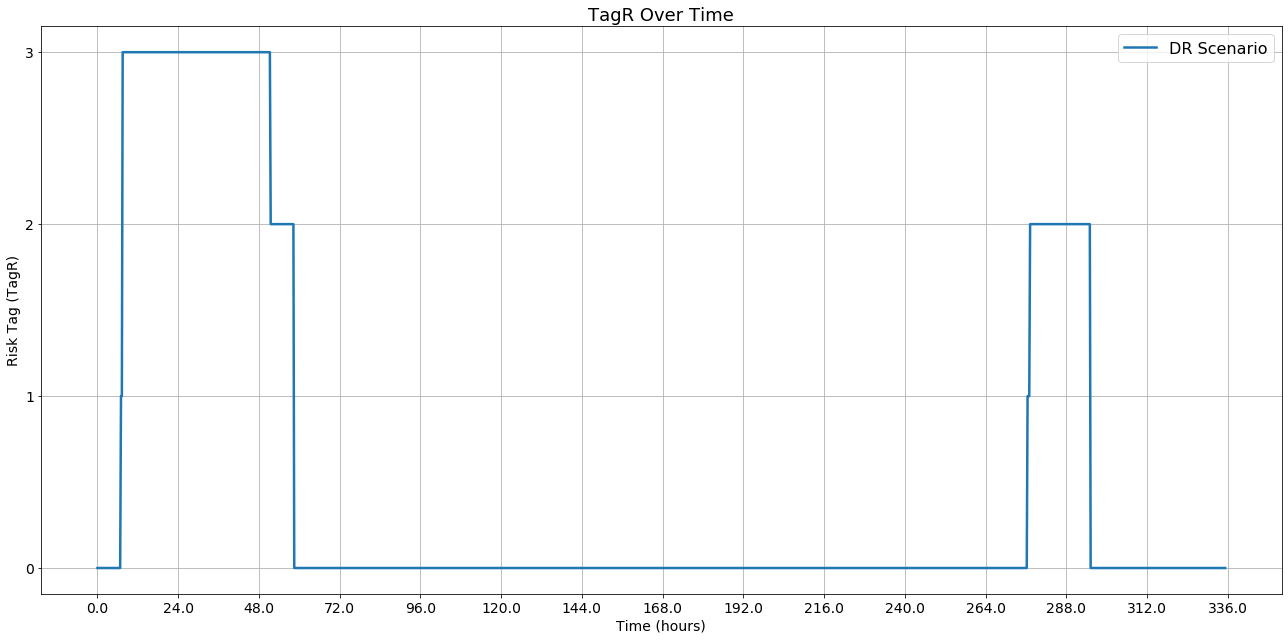

In [51]:
# Step 8: Plotting script
plt.figure(figsize=(18, 9))

#plt.plot(nominal["tagR"], label="Nominal")
plt.plot(iteration["tagR"], label="DR Scenario", linewidth=2.5)

# Set up time axis in hours
total_steps = 1344
time_step_hr = 0.25
xtick_interval = 96  # every 12 hours → 12 / 0.25 = 48 steps
ytick_interval = 1

plt.xticks(
    ticks=range(0, total_steps + 1, xtick_interval),
    labels=[f"{x * time_step_hr:.1f}" for x in range(0, total_steps + 1, xtick_interval)],
    fontsize=14
)
plt.yticks(
    ticks=range(0, 4, ytick_interval),
    #labels=[f"{x * time_step_hr:.1f}" for x in range(0, 3, ytick_interval)],
    fontsize=14
)

# Labels and title with larger font
plt.xlabel("Time (hours)", fontsize=14)
plt.ylabel("Risk Tag (TagR)", fontsize=14)
plt.title("TagR Over Time", fontsize=18)

# Larger legend font and enable grid
plt.legend(fontsize=16)
plt.grid(True)
plt.tight_layout()
plt.show()

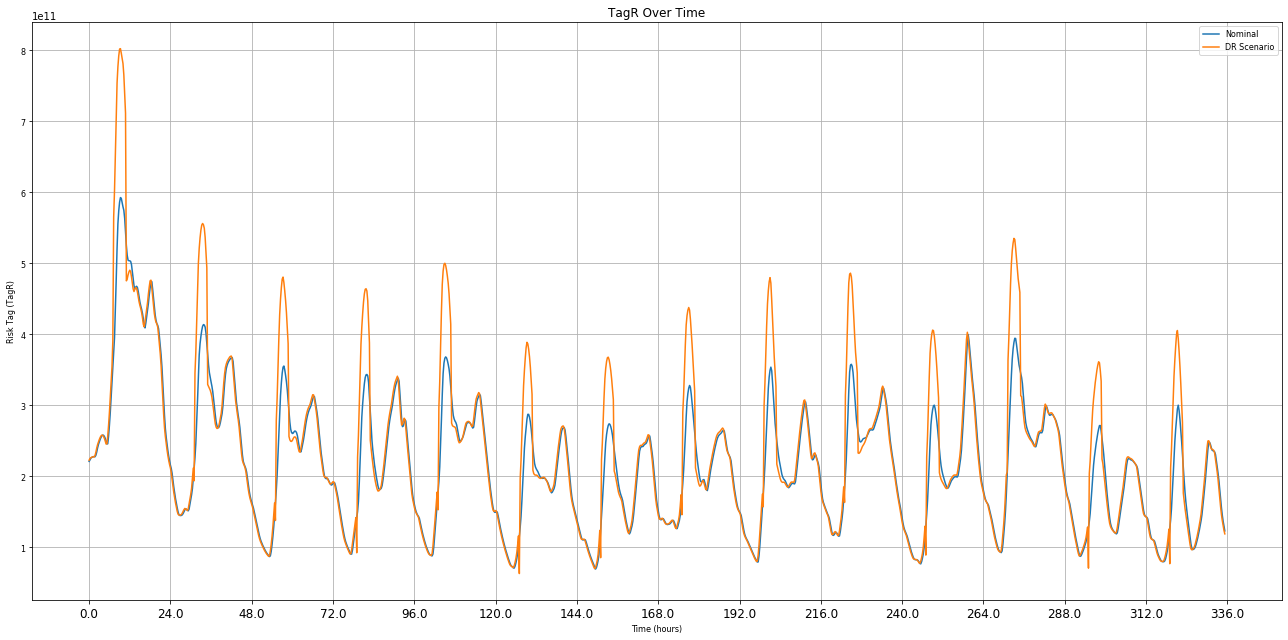

In [ ]:
# Step 8: Plotting script
plt.figure(figsize=(18, 9))

plt.plot(nominal["EQIvecinst"], label="Nominal")
plt.plot(iteration["EQIvecinst"], label="DR Scenario")

# Set up time axis in hours
total_steps = 1344
time_step_hr = 0.25
xtick_interval = 96  # every 12 hours → 12 / 0.25 = 48 steps

plt.xticks(
    ticks=range(0, total_steps + 1, xtick_interval),
    labels=[f"{x * time_step_hr:.1f}" for x in range(0, total_steps + 1, xtick_interval)],
    fontsize=12
)
plt.yticks(fontsize=8)

# Labels and title with larger font
plt.xlabel("Time (hours)", fontsize=8)
plt.ylabel("Risk Tag (TagR)", fontsize=8)
plt.title("Effluent Quality Index", fontsize=12)

# Larger legend font and enable grid
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

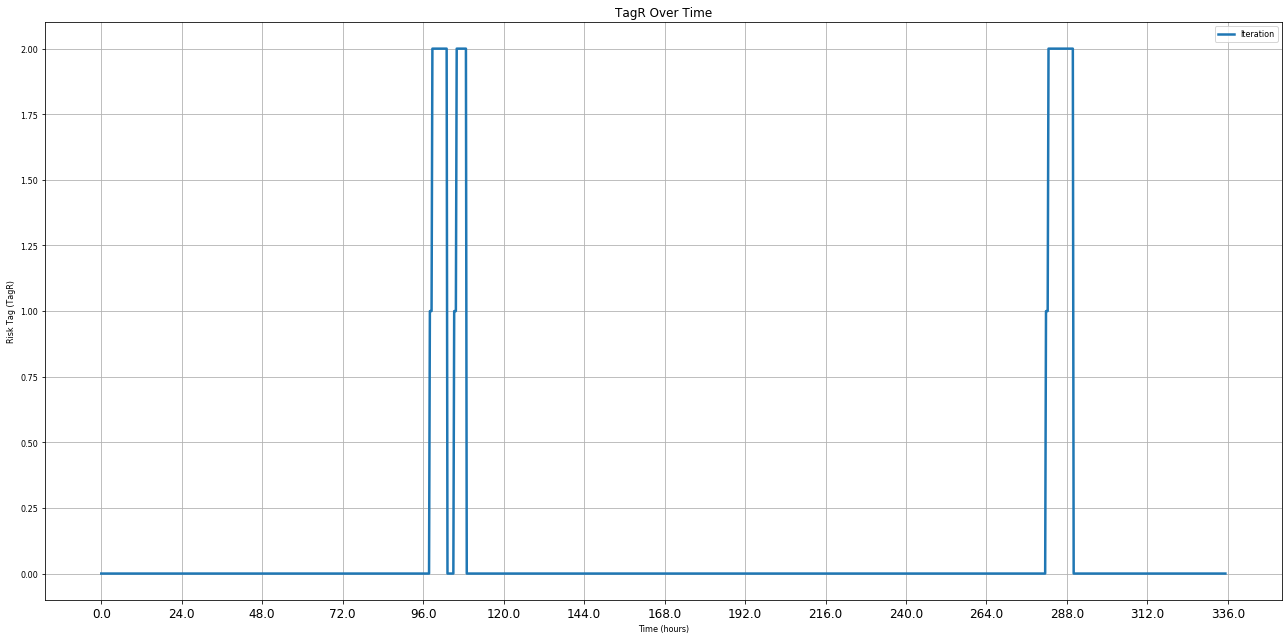

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 9))

# Thicker line width
#plt.plot(nominal["tagR"], label="Nominal", linewidth=2.5)
plt.plot(iteration["tagR"], label="Iteration", linewidth=2.5)

# Time axis setup
total_steps = 1344
time_step_hr = 0.25
xtick_interval = 96  # every 12 hours

plt.xticks(
    ticks=range(0, total_steps + 1, xtick_interval),
    labels=[f"{x * time_step_hr:.1f}" for x in range(0, total_steps + 1, xtick_interval)],
    fontsize=12
)
plt.yticks(fontsize=8)

# Labels and title with larger font
plt.xlabel("Time (hours)", fontsize=8)
plt.ylabel("Risk Tag (TagR)", fontsize=8)
plt.title("TagR Over Time", fontsize=12)

# Larger legend font and enable grid
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()
